**Step 1: Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import lag_plot
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

**Step 2: Upload and Load Dataset**

In [ ]:
df = pd.read_csv("Tesla_stock_price.csv")
df.head(10)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.471878,25.620893,17.975619,24.483324,24.483324,18766300
1,2010-07-01,25.833160,26.783820,20.945526,22.691846,22.691846,8218800
2,2010-07-02,24.785360,24.893122,20.162350,20.690388,20.690388,5139800
3,2010-07-06,19.801916,19.801916,15.673216,15.950444,15.950444,6866900
4,2010-07-07,16.244979,16.472803,14.838401,15.650650,15.650650,6921700
5,2010-07-08,17.462091,18.955133,16.845401,18.890217,18.890217,7711400
6,2010-07-09,18.312870,18.646210,17.239930,18.125366,18.125366,4050600
7,2010-07-12,17.592621,17.710231,16.661534,16.710538,16.710538,2202500
8,2010-07-13,17.935092,19.224274,17.429734,18.708601,18.708601,2680100
9,2010-07-14,17.604262,19.772902,17.427630,19.468703,19.468703,4195200


**Step 3: Visualizing Closing Price**

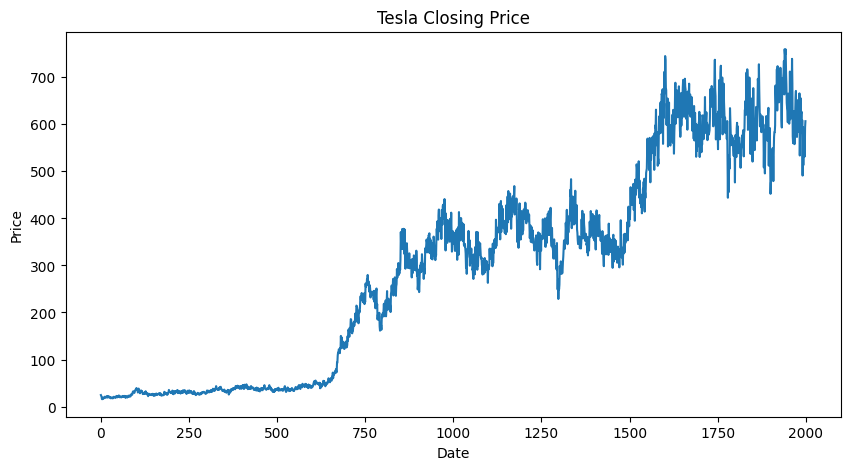

In [ ]:
plt.figure(figsize=(10,5))
df['Close'].plot()
plt.title("Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

**Step 4: Cumulative Returns Visualization**

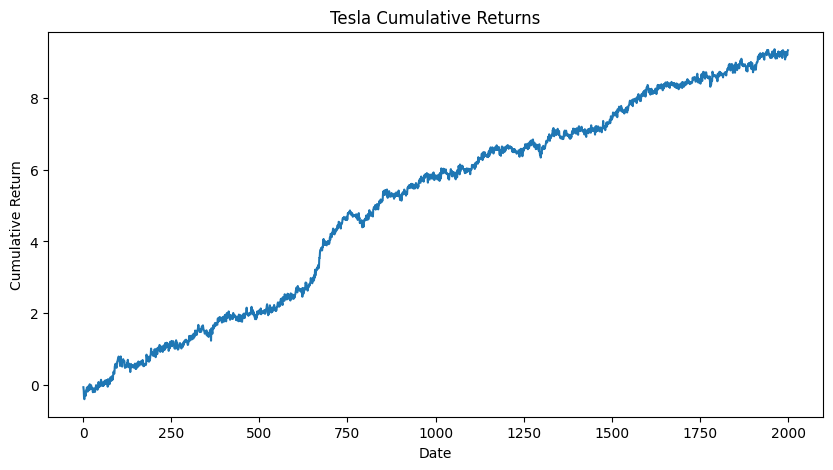

In [ ]:
returns = df['Close'].pct_change()
cumulative_returns = returns.cumsum()
plt.figure(figsize=(10,5))
cumulative_returns.plot()
plt.title("Tesla Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()


**Step 5: Autocorrelation Plot**

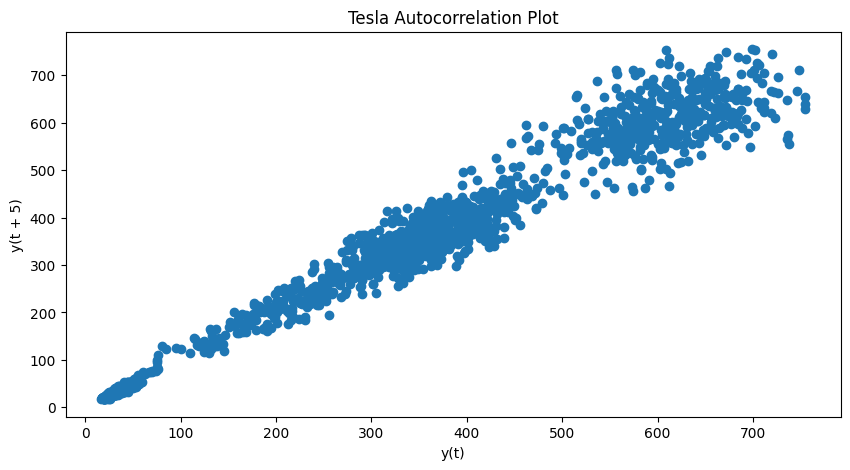

In [ ]:
plt.figure(figsize=(10,5))
lag_plot(df['Open'], lag=5)
plt.title("Tesla Autocorrelation Plot")
plt.show()


**Step 6: Stationarity Check using ADF Test**

In [ ]:
def adf_test(series):
  result = adfuller(series.dropna())
  print("ADF Statistic:", result[0])
  print("p-value:", result[1])

  if result[1] <= 0.05:
    print("Data is Stationary")
  else:
   print("Data is Non-Stationary")
adf_test(df['Open'])

ADF Statistic: -0.8136927399969814
p-value: 0.815066802958604
Data is Non-Stationary


**Step 7: Train and Test Split**

In [ ]:
train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

**Step 8: Training and Testing Visualization**

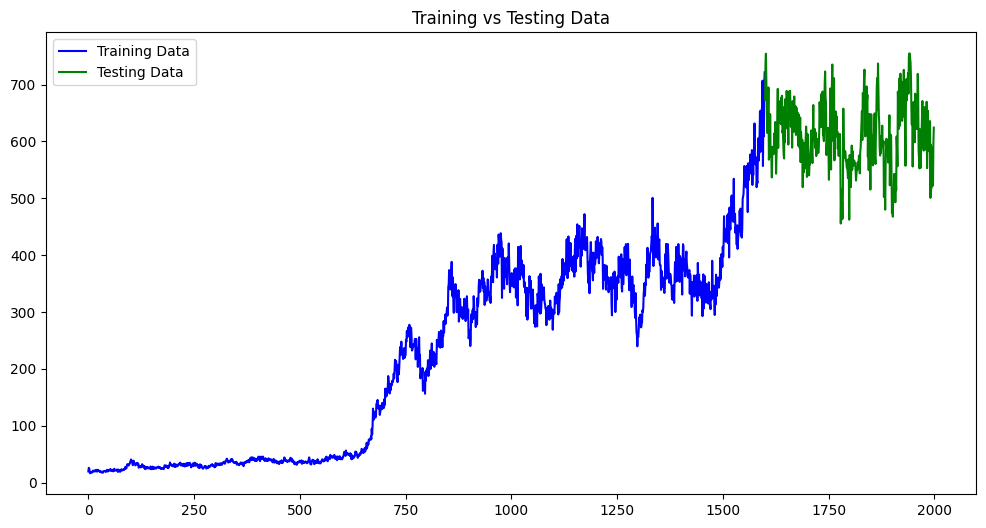

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train_data['Open'], color='blue', label='Training Data')
plt.plot(test_data['Open'], color='green', label='Testing Data')
plt.title("Training vs Testing Data")
plt.legend()
plt.show()


**Step 9: Define SMAPE Function**

In [ ]:
def smape_kun(y_true, y_pred):
   return np.mean(
    (np.abs(y_pred - y_true) * 200) /
    (np.abs(y_pred) + np.abs(y_true))
)

**Step 10: ARIMA Model Prediction (Walk-Forward Validation)**

In [ ]:
train_ar = train_data['Open'].values
test_ar = test_data['Open'].values

history = list(train_ar)
predictions = []

for t in range(len(test_ar)):
  model = ARIMA(history, order=(5,1,0))
  model_fit = model.fit()
  output = model_fit.forecast()
  yhat = output[0]
  predictions.append(yhat)
  history.append(test_ar[t])


**Step 11: Error Calculation**

In [ ]:
mse_error = mean_squared_error(test_ar, predictions)
print("Testing Mean Squared Error:", mse_error)
smape_error = smape_kun(test_ar, predictions)
print("SMAPE Error:", smape_error)

Testing Mean Squared Error: 1793.76120769122
SMAPE Error: 5.3568859223410605


**Step 12: Final Prediction Visualization**

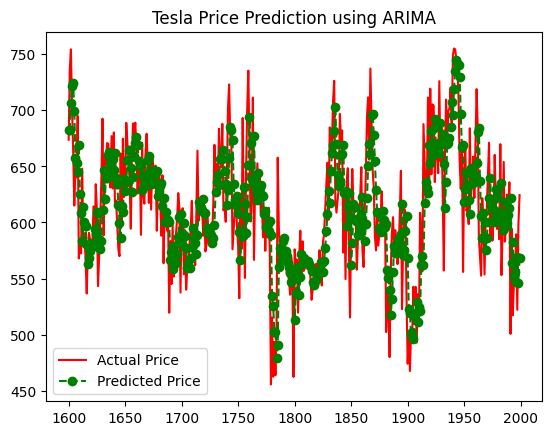

In [ ]:
plt.plot(test_data.index, test_data['Open'],
color='red', label='Actual Price')
plt.plot(test_data.index, predictions,
color='green', linestyle='dashed', marker='o',
label='Predicted Price')
plt.title("Tesla Price Prediction using ARIMA")
plt.legend()
plt.show()